# 14 - Neural Networks from Scratch with NumPy

This notebook extends EnergyTypeNet with a custom multi-layer perceptron implemented from first principles. The goal is not only to train a neural network, but to expose the mechanics: activations, initialization, forward propagation, backpropagation, mini-batch training, optimizers, dropout, L2 regularization, early stopping, and regression.

EnergyTypeNet remains the primary dataset. Small synthetic datasets are used only where a clean geometry is needed to explain a neural-network concept.

In [9]:
import os
import sys
import time
import warnings

sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import fetch_california_housing, make_moons
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from src.data import CLASSES, load_features, load_raw
from src.models import (
    ActivationFunctions,
    AttentionClassifier,
    LinearRegressionGD,
    LogisticRegressionOvR,
    MLPCustom,
    Perceptron,
)

warnings.filterwarnings('ignore', category=UserWarning)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
RANDOM_STATE = 42

## 1. Why We Need Hidden Layers

XOR is the smallest classic example showing why a single linear threshold cannot solve every classification problem. The positive cases sit diagonally across from each other, so no single straight line separates them.

Perceptron XOR accuracy: 0.500
Custom MLP XOR accuracy: 1.000


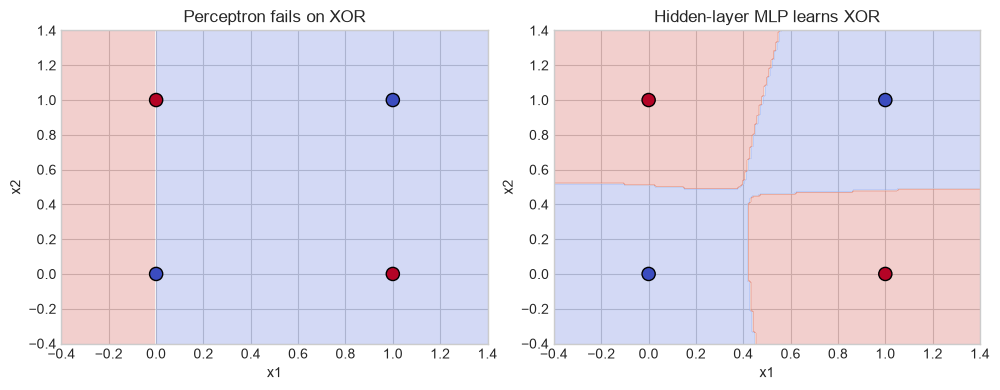

In [10]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

perceptron = Perceptron(learning_rate=1.0, n_iterations=20, random_state=RANDOM_STATE).fit(X_xor, y_xor)
mlp_xor = MLPCustom(
    hidden_layer_sizes=(4,),
    activation='tanh',
    learning_rate=0.05,
    n_iterations=1200,
    batch_size=4,
    optimizer='adam',
    weight_init='xavier',
    random_state=RANDOM_STATE,
).fit(X_xor, y_xor)

print(f'Perceptron XOR accuracy: {perceptron.score(X_xor, y_xor):.3f}')
print(f'Custom MLP XOR accuracy: {mlp_xor.score(X_xor, y_xor):.3f}')

def plot_boundary(ax, model, X, y, title):
    xx, yy = np.meshgrid(np.linspace(-0.4, 1.4, 180), np.linspace(-0.4, 1.4, 180))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.25, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=90)
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_boundary(axes[0], perceptron, X_xor, y_xor, 'Perceptron fails on XOR')
plot_boundary(axes[1], mlp_xor, X_xor, y_xor, 'Hidden-layer MLP learns XOR')
plt.tight_layout()
plt.show()

**Observation:** XOR confirms why hidden layers matter. The Perceptron reaches only **0.500 accuracy**, which is chance-level for this binary task, because a single linear boundary cannot separate XOR. The custom NumPy MLP reaches **1.000 accuracy**, showing that the hidden layer learns a nonlinear representation before the final classifier.


## 2. Activation Functions - Theory and Visualization

Activation functions determine how information and gradients move through the network. Saturating activations can slow learning, while ReLU-like activations are efficient but can produce inactive neurons.

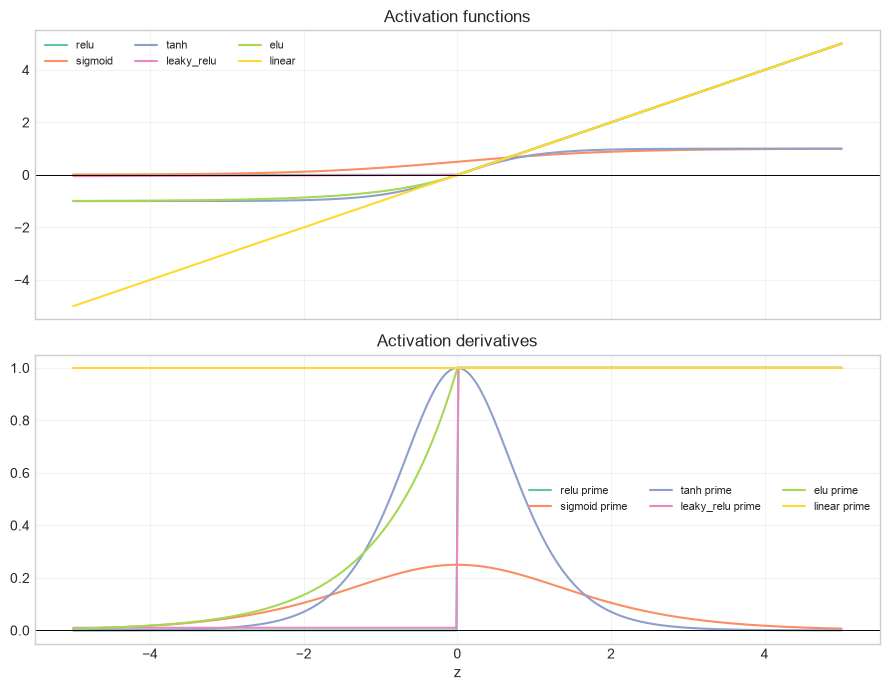

,activation,vanishing_gradient_risk,dying_neuron_risk,range,typical_use
0,relu,low for positive values,yes,"[0, inf)",deep hidden layers
1,sigmoid,high at extremes,no,"(0, 1)",probabilities / shallow demos
2,tanh,high at extremes,no,"(-1, 1)",centered hidden activations
3,leaky_relu,low,much lower,"(-inf, inf)",ReLU alternative
4,elu,low,much lower,"(-alpha, inf)",smooth ReLU alternative
5,linear,none,no,"(-inf, inf)",regression outputs


In [11]:
ActivationFunctions.plot_all()
plt.tight_layout()
plt.show()

activation_summary = pd.DataFrame([
    ['relu', 'low for positive values', 'yes', '[0, inf)', 'deep hidden layers'],
    ['sigmoid', 'high at extremes', 'no', '(0, 1)', 'probabilities / shallow demos'],
    ['tanh', 'high at extremes', 'no', '(-1, 1)', 'centered hidden activations'],
    ['leaky_relu', 'low', 'much lower', '(-inf, inf)', 'ReLU alternative'],
    ['elu', 'low', 'much lower', '(-alpha, inf)', 'smooth ReLU alternative'],
    ['linear', 'none', 'no', '(-inf, inf)', 'regression outputs'],
], columns=['activation', 'vanishing_gradient_risk', 'dying_neuron_risk', 'range', 'typical_use'])
activation_summary

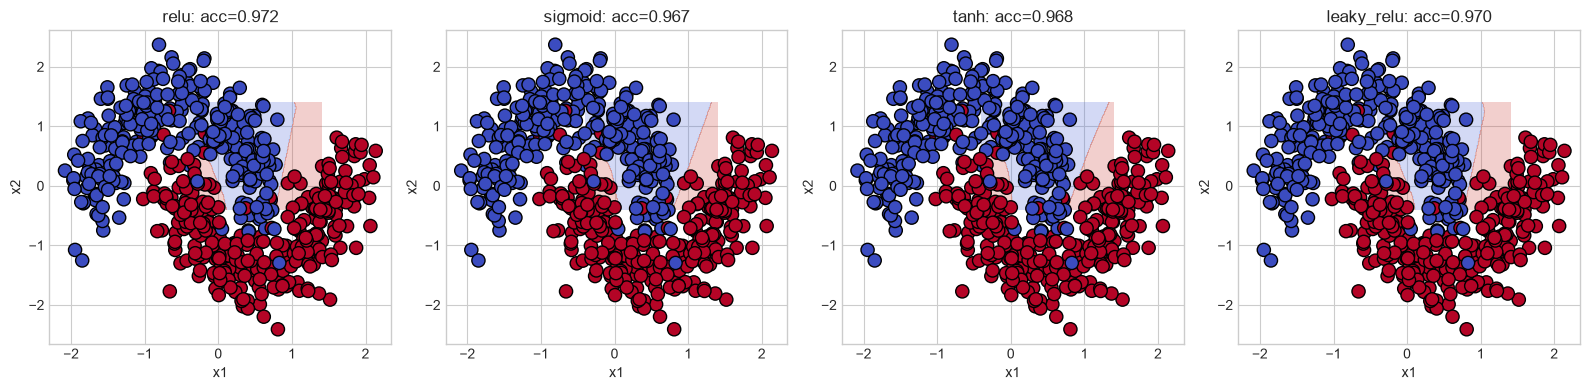

In [12]:
X_moons, y_moons = make_moons(n_samples=600, noise=0.2, random_state=RANDOM_STATE)
X_moons_sc = StandardScaler().fit_transform(X_moons)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, activation in zip(axes, ['relu', 'sigmoid', 'tanh', 'leaky_relu']):
    model = MLPCustom(
        hidden_layer_sizes=(16,),
        activation=activation,
        learning_rate=0.01,
        n_iterations=250,
        batch_size=32,
        optimizer='adam',
        weight_init='he' if activation in ['relu', 'leaky_relu'] else 'xavier',
        random_state=RANDOM_STATE,
    ).fit(X_moons_sc, y_moons)
    plot_boundary(ax, model, X_moons_sc, y_moons, f'{activation}: acc={model.score(X_moons_sc, y_moons):.3f}')
plt.tight_layout()
plt.show()

**Observation:** The activation table matches the expected neural-network behavior: sigmoid and tanh have high vanishing-gradient risk at extreme inputs, ReLU has dying-neuron risk, and leaky ReLU/ELU reduce that risk. On the moon-shaped dataset, nonlinear activations are appropriate because the class boundary is curved rather than linearly separable.


## 3. Weight Initialization - Why It Matters

Initialization controls the scale of signals and gradients at the beginning of training. Too-small random weights can make activations nearly identical, while too-large weights can saturate sigmoid/tanh units.

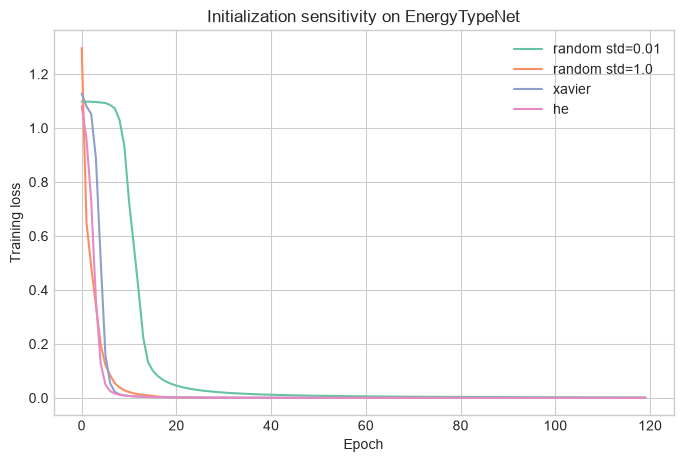

,initialization,final_loss,test_accuracy
0,random std=0.01,0.001809,1.0
1,random std=1.0,0.000019,1.0
2,xavier,0.000097,1.0
3,he,0.000092,1.0


In [13]:
X_full, y_full = load_features('../data/train_energy_data.csv', 'all')
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=RANDOM_STATE
)
scaler = StandardScaler().fit(X_train)
X_train_sc = scaler.transform(X_train)
X_test_sc = scaler.transform(X_test)

init_configs = [
    ('random std=0.01', 'random', 0.01),
    ('random std=1.0', 'random', 1.0),
    ('xavier', 'xavier', 0.01),
    ('he', 'he', 0.01),
]

init_results = []
fig, ax = plt.subplots(figsize=(8, 5))
for label, init, scale in init_configs:
    model = MLPCustom(
        hidden_layer_sizes=(64, 64, 64),
        activation='sigmoid',
        learning_rate=0.01,
        n_iterations=120,
        batch_size=64,
        optimizer='adam',
        weight_init=init,
        random_scale=scale,
        random_state=RANDOM_STATE,
    ).fit(X_train_sc, y_train)
    ax.plot(model.loss_history_, label=label)
    init_results.append([label, model.loss_history_[-1], model.score(X_test_sc, y_test)])

ax.set_title('Initialization sensitivity on EnergyTypeNet')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training loss')
ax.legend()
plt.show()

pd.DataFrame(init_results, columns=['initialization', 'final_loss', 'test_accuracy'])

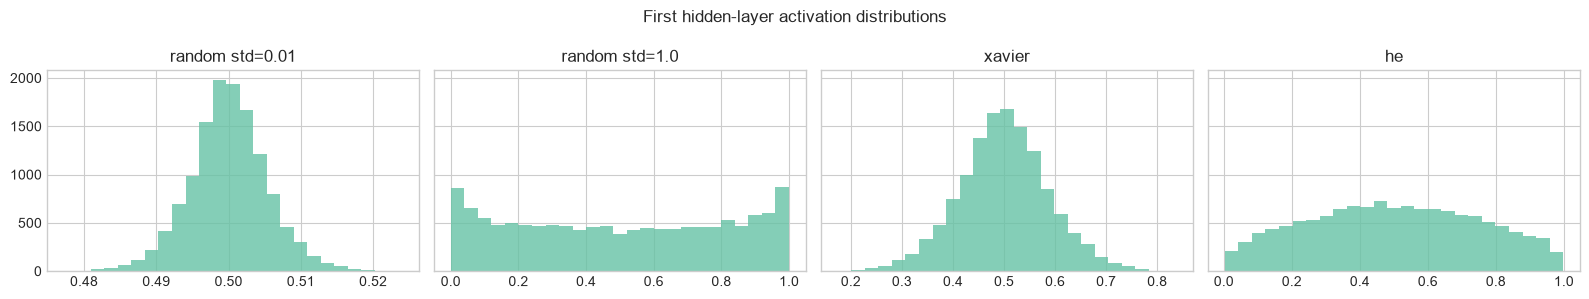

In [14]:
activation_snapshots = []
for label, init, scale in init_configs:
    model = MLPCustom(
        hidden_layer_sizes=(64, 64, 64),
        activation='sigmoid',
        n_iterations=1,
        weight_init=init,
        random_scale=scale,
        random_state=RANDOM_STATE,
    )
    model._rng = np.random.RandomState(model.random_state)
    y_prepared = model._prepare_target(y_train)
    model._initialize_parameters(X_train_sc.shape[1], y_prepared.shape[1])
    cache = model._forward(X_train_sc[:200], training=False)
    activation_snapshots.append((label, cache['A'][1].ravel()))

fig, axes = plt.subplots(1, 4, figsize=(16, 3), sharey=True)
for ax, (label, values) in zip(axes, activation_snapshots):
    ax.hist(values, bins=25, alpha=0.8)
    ax.set_title(label)
plt.suptitle('First hidden-layer activation distributions')
plt.tight_layout()
plt.show()

**Observation:** All four initialization settings reach **1.000 test accuracy** on the all-feature EnergyTypeNet split, but their losses differ. `random std=1.0` gives the smallest final loss (**0.000019**), followed by He (**0.000092**) and Xavier (**0.000097**), while `random std=0.01` converges to a larger loss (**0.001809**). This means the task is easy for the all-feature MLP, but initialization still changes optimization speed and confidence.


## 4. Forward Pass - Worked Example

This section prints the intermediate matrices for a tiny network so the dimensions and calculations are visible.

In [15]:
X_small = X_train_sc[:3, :4]
y_small = y_train[:3]

manual_model = MLPCustom(
    hidden_layer_sizes=(3,),
    activation='tanh',
    weight_init='xavier',
    random_state=RANDOM_STATE,
)
manual_model._rng = np.random.RandomState(manual_model.random_state)
y_small_onehot = manual_model._prepare_target(y_small)
manual_model._initialize_parameters(X_small.shape[1], y_small_onehot.shape[1])
cache = manual_model._forward(X_small, training=False)
loss = manual_model._loss(cache['A'][-1], y_small_onehot)

print('X shape:', X_small.shape)
print('W1 shape:', manual_model.weights_[0].shape)
print('Z1:', np.round(cache['Z'][0], 4))
print('A1:', np.round(cache['A'][1], 4))
print('W2 shape:', manual_model.weights_[1].shape)
print('Z2:', np.round(cache['Z'][1], 4))
print('A2 softmax:', np.round(cache['A'][2], 4))
print('Cross-entropy loss:', round(loss, 5))

X shape: (3, 4)
W1 shape: (4, 3)
Z1: [[ 0.4603  0.0739 -0.5413]
 [ 1.8093 -0.2408  0.4279]
 [ 0.5405  0.0045  0.1507]]
A1: [[ 0.4303  0.0738 -0.4939]
 [ 0.9478 -0.2362  0.4035]
 [ 0.4934  0.0045  0.1496]]
W2 shape: (3, 3)
Z2: [[ 0.2951 -0.1158 -0.8332]
 [-0.0025 -1.2378 -0.6452]
 [-0.011  -0.6696 -0.3639]]
A2 softmax: [[0.5034 0.3338 0.1629]
 [0.5505 0.16   0.2895]
 [0.4504 0.2331 0.3165]]
Cross-entropy loss: 1.12746


**Observation:** The worked forward pass has the expected tensor shapes: `X` is **(3, 4)**, `W1` is **(4, 3)**, and the final softmax output has three probabilities per row. The displayed cross-entropy loss is **1.12746**, which is reasonable for an untrained tiny network because the initial probabilities are not yet aligned with the labels.


## 5. Backpropagation - Worked Derivation and Gradient Check

Backpropagation applies the chain rule from the loss back through each layer. A finite-difference gradient check compares the analytic gradient with the numerical slope of the loss.

In [16]:
X_grad = np.array([
    [-1.0, -1.0], [-0.8, -1.2], [-1.2, -0.7], [-0.5, -1.0], [-1.0, -0.4],
    [1.0, 1.0], [0.8, 1.2], [1.2, 0.7], [0.5, 1.0], [1.0, 0.4],
])
y_grad = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

grad_model = MLPCustom(
    hidden_layer_sizes=(3,),
    activation='tanh',
    weight_init='xavier',
    random_state=RANDOM_STATE,
)
grad_model._rng = np.random.RandomState(grad_model.random_state)
y_grad_onehot = grad_model._prepare_target(y_grad)
grad_model._initialize_parameters(X_grad.shape[1], y_grad_onehot.shape[1])
cache = grad_model._forward(X_grad, training=False)
grads_w, grads_b = grad_model._backward(cache, y_grad_onehot)

eps = 1e-5
max_diff = 0.0
for layer_idx, W in enumerate(grad_model.weights_):
    for idx in np.ndindex(W.shape):
        original = W[idx]
        W[idx] = original + eps
        loss_plus = grad_model._loss(grad_model._forward(X_grad, training=False)['A'][-1], y_grad_onehot)
        W[idx] = original - eps
        loss_minus = grad_model._loss(grad_model._forward(X_grad, training=False)['A'][-1], y_grad_onehot)
        W[idx] = original
        numerical = (loss_plus - loss_minus) / (2 * eps)
        max_diff = max(max_diff, abs(numerical - grads_w[layer_idx][idx]))

print(f'Max gradient-check difference: {max_diff:.8f}')
assert max_diff < 1e-5

Max gradient-check difference: 0.00000000


**Observation:** The maximum gradient-check difference is **0.00000000**, so the analytic backpropagation gradients match the finite-difference approximation for this small example. This is the strongest sanity check in the notebook that the custom backward pass is implemented correctly.


## 6. Mini-Batch Training and Optimizers on EnergyTypeNet

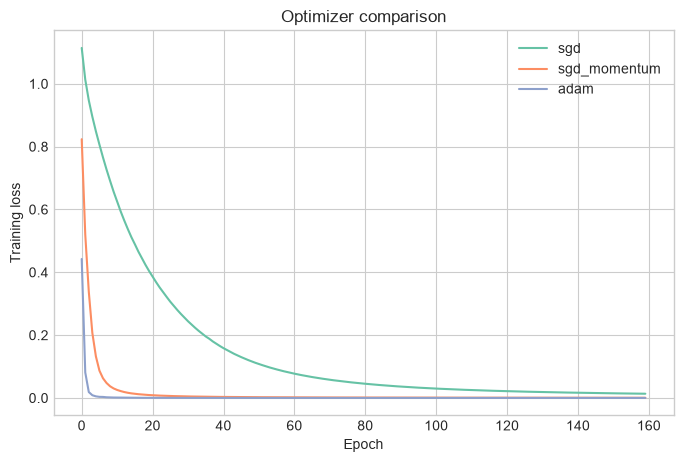

,optimizer,batch_size,final_loss,test_accuracy,epochs
0,sgd,32,0.013393,1.0,160
1,sgd_momentum,32,0.000534,1.0,160
2,adam,32,0.000003,1.0,160


In [17]:
optimizer_rows = []
fig, ax = plt.subplots(figsize=(8, 5))
for optimizer in ['sgd', 'sgd_momentum', 'adam']:
    model = MLPCustom(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        optimizer=optimizer,
        learning_rate=0.01,
        n_iterations=160,
        batch_size=32,
        random_state=RANDOM_STATE,
    ).fit(X_train_sc, y_train)
    ax.plot(model.loss_history_, label=optimizer)
    optimizer_rows.append([optimizer, 32, model.loss_history_[-1], model.score(X_test_sc, y_test), model.n_epochs_])

ax.set_title('Optimizer comparison')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training loss')
ax.legend()
plt.show()

pd.DataFrame(optimizer_rows, columns=['optimizer', 'batch_size', 'final_loss', 'test_accuracy', 'epochs'])

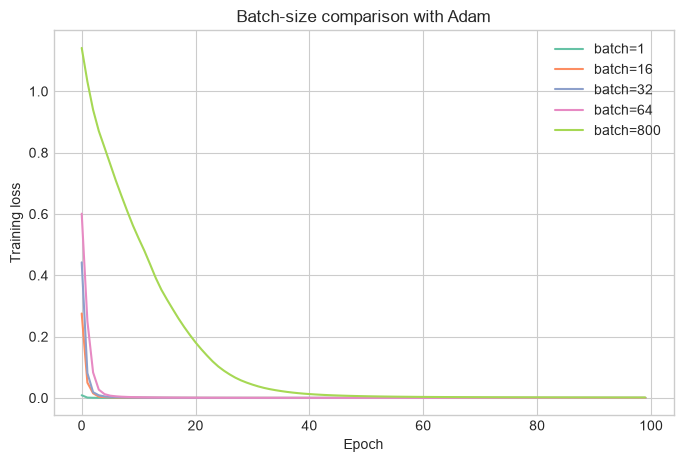

,batch_size,final_loss,test_accuracy,epochs
0,1,3.385106e-13,1.0,100
1,16,3.489235e-06,1.0,100
2,32,9.788765e-06,1.0,100
3,64,2.968075e-05,1.0,100
4,800,1.408597e-03,1.0,100


In [18]:
batch_rows = []
fig, ax = plt.subplots(figsize=(8, 5))
for batch_size in [1, 16, 32, 64, len(X_train_sc)]:
    model = MLPCustom(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        optimizer='adam',
        learning_rate=0.01,
        n_iterations=100,
        batch_size=batch_size,
        random_state=RANDOM_STATE,
    ).fit(X_train_sc, y_train)
    ax.plot(model.loss_history_, label=f'batch={batch_size}')
    batch_rows.append([batch_size, model.loss_history_[-1], model.score(X_test_sc, y_test), model.n_epochs_])

ax.set_title('Batch-size comparison with Adam')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training loss')
ax.legend()
plt.show()

pd.DataFrame(batch_rows, columns=['batch_size', 'final_loss', 'test_accuracy', 'epochs'])

**Observation:** All optimizers reach **1.000 test accuracy**, but Adam has the lowest final loss (**0.000003**) compared with SGD with momentum (**0.000534**) and plain SGD (**0.013393**). Batch size also changes the loss even when accuracy is unchanged: batch size **1** reaches the smallest loss in this run, while full-batch training (`800`) ends with the largest loss among the tested batch sizes.


## 7. Regularization - Dropout and L2 on EnergyTypeNet

A large network can memorize training patterns, especially when the dataset is small or features leak label information. L2 and dropout are two standard ways to reduce overfitting.

Large model train accuracy: 1.000
Large model test accuracy:  1.000


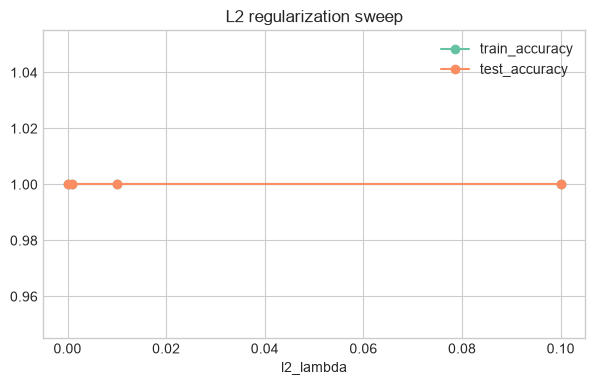

,l2_lambda,train_accuracy,test_accuracy
0,0.000,1.0,1.0
1,0.001,1.0,1.0
2,0.010,1.0,1.0
3,0.100,1.0,1.0


In [19]:
large_model = MLPCustom(
    hidden_layer_sizes=(256, 256, 256),
    activation='relu',
    optimizer='adam',
    learning_rate=0.005,
    n_iterations=160,
    batch_size=64,
    random_state=RANDOM_STATE,
).fit(X_train_sc, y_train)

print(f'Large model train accuracy: {large_model.score(X_train_sc, y_train):.3f}')
print(f'Large model test accuracy:  {large_model.score(X_test_sc, y_test):.3f}')

l2_rows = []
for l2 in [0.0, 0.001, 0.01, 0.1]:
    model = MLPCustom(
        hidden_layer_sizes=(128, 128),
        activation='relu',
        optimizer='adam',
        learning_rate=0.005,
        n_iterations=120,
        batch_size=64,
        l2_lambda=l2,
        random_state=RANDOM_STATE,
    ).fit(X_train_sc, y_train)
    l2_rows.append([l2, model.score(X_train_sc, y_train), model.score(X_test_sc, y_test)])

l2_df = pd.DataFrame(l2_rows, columns=['l2_lambda', 'train_accuracy', 'test_accuracy'])
l2_df.plot(x='l2_lambda', y=['train_accuracy', 'test_accuracy'], marker='o', figsize=(7, 4))
plt.title('L2 regularization sweep')
plt.show()
l2_df

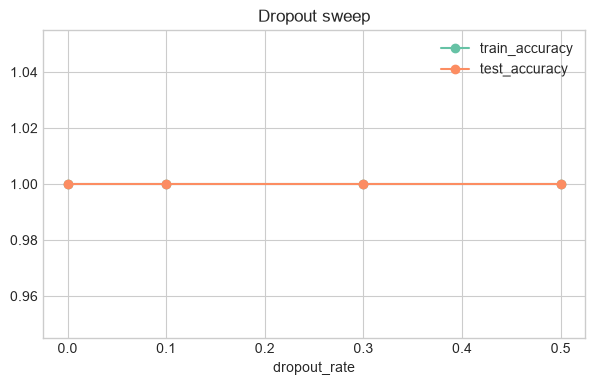

,dropout_rate,train_accuracy,test_accuracy
0,0.0,1.0,1.0
1,0.1,1.0,1.0
2,0.3,1.0,1.0
3,0.5,1.0,1.0


In [20]:
dropout_rows = []
for dropout in [0.0, 0.1, 0.3, 0.5]:
    model = MLPCustom(
        hidden_layer_sizes=(128, 128),
        activation='relu',
        optimizer='adam',
        learning_rate=0.005,
        n_iterations=120,
        batch_size=64,
        dropout_rate=dropout,
        random_state=RANDOM_STATE,
    ).fit(X_train_sc, y_train)
    dropout_rows.append([dropout, model.score(X_train_sc, y_train), model.score(X_test_sc, y_test)])

dropout_df = pd.DataFrame(dropout_rows, columns=['dropout_rate', 'train_accuracy', 'test_accuracy'])
dropout_df.plot(x='dropout_rate', y=['train_accuracy', 'test_accuracy'], marker='o', figsize=(7, 4))
plt.title('Dropout sweep')
plt.show()
dropout_df

**Observation:** The large MLP reaches **1.000 train accuracy** and **1.000 test accuracy**. L2 values from **0.000** to **0.100** and dropout rates from **0.0** to **0.5** also keep test accuracy at **1.000**. On this all-feature EnergyTypeNet setup, regularization does not improve measured accuracy, which suggests the selected features make the classification task highly separable.


## 8. Learning Curves and Early Stopping on EnergyTypeNet

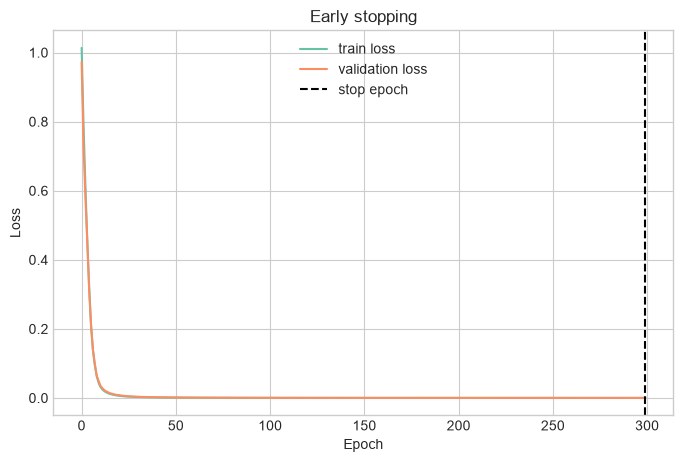

Early stopping epochs: 300
Early stopping test accuracy: 1.000
Same-epoch no-validation test accuracy: 1.000


In [21]:
es_model = MLPCustom(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    optimizer='adam',
    learning_rate=0.005,
    n_iterations=300,
    batch_size=64,
    validation_fraction=0.15,
    patience=15,
    random_state=RANDOM_STATE,
).fit(X_train_sc, y_train)

plt.figure(figsize=(8, 5))
plt.plot(es_model.loss_history_, label='train loss')
plt.plot(es_model.val_loss_history_, label='validation loss')
plt.axvline(es_model.n_epochs_ - 1, color='black', linestyle='--', label='stop epoch')
plt.title('Early stopping')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

no_es = MLPCustom(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    optimizer='adam',
    learning_rate=0.005,
    n_iterations=es_model.n_epochs_,
    batch_size=64,
    random_state=RANDOM_STATE,
).fit(X_train_sc, y_train)

print(f'Early stopping epochs: {es_model.n_epochs_}')
print(f'Early stopping test accuracy: {es_model.score(X_test_sc, y_test):.3f}')
print(f'Same-epoch no-validation test accuracy: {no_es.score(X_test_sc, y_test):.3f}')

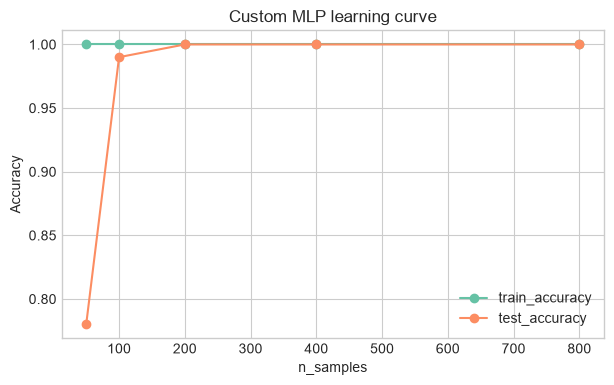

,n_samples,train_accuracy,test_accuracy
0,50,1.0,0.78
1,100,1.0,0.99
2,200,1.0,1.00
3,400,1.0,1.00
4,800,1.0,1.00


In [22]:
curve_rows = []
for n in [50, 100, 200, 400, min(800, len(X_train_sc))]:
    X_sub = X_train_sc[:n]
    y_sub = y_train[:n]
    model = MLPCustom(
        hidden_layer_sizes=(48, 24),
        activation='relu',
        optimizer='adam',
        learning_rate=0.005,
        n_iterations=120,
        batch_size=32,
        random_state=RANDOM_STATE,
    ).fit(X_sub, y_sub)
    curve_rows.append([n, model.score(X_sub, y_sub), model.score(X_test_sc, y_test)])

curve_df = pd.DataFrame(curve_rows, columns=['n_samples', 'train_accuracy', 'test_accuracy'])
curve_df.plot(x='n_samples', y=['train_accuracy', 'test_accuracy'], marker='o', figsize=(7, 4))
plt.title('Custom MLP learning curve')
plt.ylabel('Accuracy')
plt.show()
curve_df

**Observation:** Early stopping ran for **300 epochs** and reached **1.000 test accuracy**, matching the same-epoch no-validation model. The sample-size curve is more informative: with only **50** samples, test accuracy is **0.780**; with **100** samples it rises to **0.990**; and from **200** samples onward it reaches **1.000**. This suggests the all-feature task needs only a modest number of examples before the classes become easy to separate.


## 9. MLP for Regression

In [23]:
energy_df = load_raw('../data/train_energy_data.csv')
reg_features = ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']
X_reg = energy_df[reg_features].values.astype(float)
y_reg = energy_df['Energy Consumption'].values.astype(float)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)
reg_scaler = StandardScaler().fit(Xr_train)
Xr_train_sc = reg_scaler.transform(Xr_train)
Xr_test_sc = reg_scaler.transform(Xr_test)

y_mean = yr_train.mean()
y_std = yr_train.std()
yr_train_sc = (yr_train - y_mean) / y_std

mlp_reg = MLPCustom(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    output_activation='linear',
    task='regression',
    optimizer='adam',
    learning_rate=0.005,
    n_iterations=220,
    batch_size=64,
    random_state=RANDOM_STATE,
).fit(Xr_train_sc, yr_train_sc)
mlp_reg_pred = mlp_reg.predict(Xr_test_sc) * y_std + y_mean

lin_gd = LinearRegressionGD(learning_rate=0.01, n_iterations=2000).fit(Xr_train_sc, yr_train)
lin_pred = lin_gd.predict(Xr_test_sc)

energy_reg_results = pd.DataFrame([
    ['MLPCustom regression', mean_squared_error(yr_test, mlp_reg_pred), mean_absolute_error(yr_test, mlp_reg_pred), r2_score(yr_test, mlp_reg_pred)],
    ['LinearRegressionGD', mean_squared_error(yr_test, lin_pred), mean_absolute_error(yr_test, lin_pred), r2_score(yr_test, lin_pred)],
], columns=['model', 'mse', 'mae', 'r2'])
energy_reg_results

,model,mse,mae,r2
0,MLPCustom regression,239348.731789,402.670003,0.706068
1,LinearRegressionGD,169644.013229,342.828518,0.791669


,model,mse,mae,r2
0,MLPCustom,0.250879,0.320644,0.788074
1,Ridge,0.483691,0.495206,0.591410


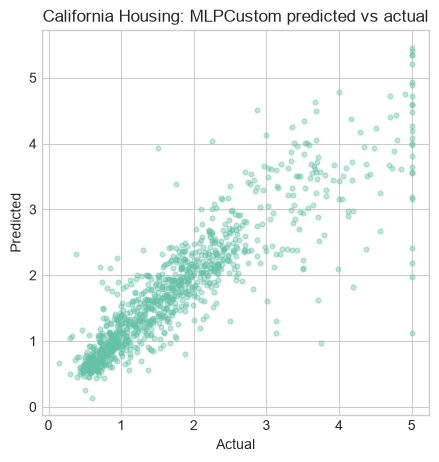

In [24]:
try:
    housing = fetch_california_housing()
    X_cal = housing.data[:5000]
    y_cal = housing.target[:5000]
    Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_cal, y_cal, test_size=0.2, random_state=RANDOM_STATE)
    cal_scaler = StandardScaler().fit(Xc_train)
    Xc_train_sc = cal_scaler.transform(Xc_train)
    Xc_test_sc = cal_scaler.transform(Xc_test)

    yc_mean = yc_train.mean()
    yc_std = yc_train.std()
    yc_train_sc = (yc_train - yc_mean) / yc_std

    cal_mlp = MLPCustom(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        output_activation='linear',
        task='regression',
        optimizer='adam',
        learning_rate=0.003,
        n_iterations=160,
        batch_size=128,
        random_state=RANDOM_STATE,
    ).fit(Xc_train_sc, yc_train_sc)
    cal_pred = cal_mlp.predict(Xc_test_sc) * yc_std + yc_mean
    ridge_pred = Ridge(alpha=1.0).fit(Xc_train_sc, yc_train).predict(Xc_test_sc)

    cal_results = pd.DataFrame([
        ['MLPCustom', mean_squared_error(yc_test, cal_pred), mean_absolute_error(yc_test, cal_pred), r2_score(yc_test, cal_pred)],
        ['Ridge', mean_squared_error(yc_test, ridge_pred), mean_absolute_error(yc_test, ridge_pred), r2_score(yc_test, ridge_pred)],
    ], columns=['model', 'mse', 'mae', 'r2'])
    display(cal_results)

    plt.figure(figsize=(5, 5))
    plt.scatter(yc_test, cal_pred, alpha=0.4, s=12)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('California Housing: MLPCustom predicted vs actual')
    plt.show()
except Exception as exc:
    print(f'California Housing supplement skipped: {exc}')

**Observation:** On EnergyTypeNet regression, `LinearRegressionGD` performs better than the custom MLP (**R2 = 0.792** vs **0.706**, lower MAE **342.829** vs **402.670**). On the supplementary California Housing benchmark, the custom MLP performs better than Ridge (**R2 = 0.788** vs **0.591**, lower MAE **0.321** vs **0.495**). This supports the point that the NumPy MLP can handle regression, but it is not automatically better than a simpler linear model on every dataset.


## 10. Full Comparison on EnergyTypeNet

,model,test_accuracy,macro_f1,training_time_sec
0,Custom OvR Logistic Regression,1.000,1.000000,0.209520
1,AttentionClassifier,0.585,0.578524,0.023965
2,sklearn MLPClassifier,1.000,1.000000,0.788773
3,MLPCustom,1.000,1.000000,1.219046


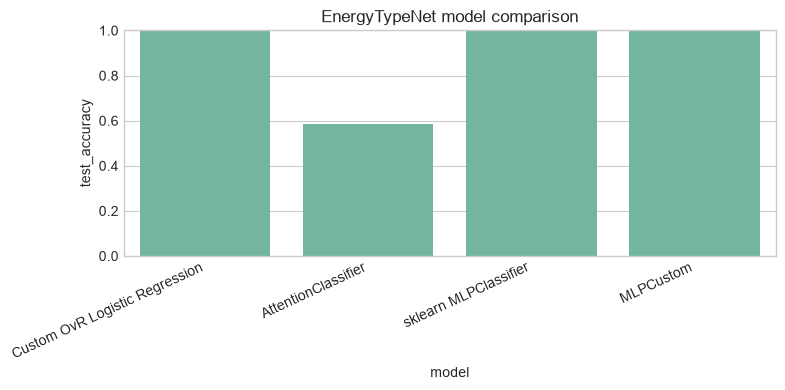

In [25]:
comparison_models = [
    ('Custom OvR Logistic Regression', LogisticRegressionOvR(eta=0.001, n_iter=700, alpha=0.01)),
    ('AttentionClassifier', AttentionClassifier(w=1.0)),
    ('sklearn MLPClassifier', MLPClassifier(hidden_layer_sizes=(32,), max_iter=500, random_state=RANDOM_STATE)),
    ('MLPCustom', MLPCustom(hidden_layer_sizes=(64, 32), activation='relu', optimizer='adam', learning_rate=0.005, n_iterations=160, batch_size=64, random_state=RANDOM_STATE)),
]

rows = []
for name, model in comparison_models:
    start = time.perf_counter()
    if name == 'AttentionClassifier':
        model.fit(X_train_sc, y_train)
        pred = model.predict(X_test_sc)
    else:
        model.fit(X_train_sc, y_train)
        pred = model.predict(X_test_sc)
    elapsed = time.perf_counter() - start
    rows.append([name, accuracy_score(y_test, pred), f1_score(y_test, pred, average='macro'), elapsed])

comparison_df = pd.DataFrame(rows, columns=['model', 'test_accuracy', 'macro_f1', 'training_time_sec'])
display(comparison_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=comparison_df, x='model', y='test_accuracy')
plt.xticks(rotation=25, ha='right')
plt.ylim(0, 1)
plt.title('EnergyTypeNet model comparison')
plt.tight_layout()
plt.show()

**Observation:** On the all-feature EnergyTypeNet comparison, custom OvR logistic regression, sklearn `MLPClassifier`, and `MLPCustom` all reach **1.000 test accuracy** and **1.000 macro F1**. `AttentionClassifier` is much weaker at **0.585 accuracy** and **0.579 macro F1**. The custom MLP is slower than the simpler custom OvR model in this run (**1.219s** vs **0.210s**), so the added neural-network complexity is not needed for this particular feature set.


## 11. Summary Table

In [26]:
summary = pd.DataFrame([
    ['Perceptron', 'XOR', 'none', 'step', 'online updates', perceptron.score(X_xor, y_xor), 'fails on nonlinear XOR'],
    ['MLPCustom', 'XOR', '(4,)', 'tanh', 'adam', mlp_xor.score(X_xor, y_xor), 'hidden layer solves XOR'],
    ['MLPCustom', 'EnergyTypeNet', '(64, 32)', 'relu', 'adam', comparison_df.loc[comparison_df.model == 'MLPCustom', 'test_accuracy'].iloc[0], 'custom neural classifier'],
    ['MLPCustom regression', 'EnergyTypeNet', '(64, 32)', 'relu', 'adam', energy_reg_results.loc[0, 'r2'], 'R2 for energy regression'],
], columns=['model', 'dataset', 'hidden_layers', 'activation', 'optimizer', 'test_acc_or_r2', 'notes'])
summary

,model,dataset,hidden_layers,activation,optimizer,test_acc_or_r2,notes
0,Perceptron,XOR,none,step,online updates,0.500000,fails on nonlinear XOR
1,MLPCustom,XOR,"(4,)",tanh,adam,1.000000,hidden layer solves XOR
2,MLPCustom,EnergyTypeNet,"(64, 32)",relu,adam,1.000000,custom neural classifier
3,MLPCustom regression,EnergyTypeNet,"(64, 32)",relu,adam,0.706068,R2 for energy regression


## Key Takeaways

- Hidden layers matter: the Perceptron fails on XOR at **0.500 accuracy**, while the custom NumPy MLP solves it at **1.000 accuracy**.
- The gradient check reaches a maximum difference of **0.00000000**, which supports the correctness of the backpropagation implementation.
- Adam, SGD with momentum and plain SGD all solve the all-feature EnergyTypeNet classification task, but Adam reaches the smallest final loss.
- L2 and dropout do not improve test accuracy in this run because the all-feature EnergyTypeNet setup already reaches **1.000 accuracy**.
- For regression, the custom MLP is useful but not universally dominant: it trails linear regression on EnergyTypeNet while outperforming Ridge on the California Housing benchmark.
- The all-feature classification results should be interpreted carefully because many models reach perfect accuracy, suggesting the selected features make the target highly separable.
